In [16]:
import os
import pandas as pd
from IPython.display import Image, Video, Markdown, display

ROOT = os.path.abspath('.')
AP1 = os.path.join(ROOT, 'apartado1')
AP2 = os.path.join(ROOT, 'apartado2')
AP3 = os.path.join(ROOT, 'apartado3')

pd.set_option('display.max_colwidth', 100)

import gymnasium as gym
import ale_py
import pandas as pd
import numpy as np

gym.register_envs(ale_py)
pd.set_option('display.max_colwidth', 120)

ENVS = ['CartPole-v1', 'LunarLander-v3', 'ALE/SpaceInvaders-v5']

def ficha(env_id):
    env = gym.make(env_id)
    spec = env.spec
    info = {
        'env_id': env_id,
        'action_space': str(env.action_space),
        'observation_space': str(env.observation_space),
        'obs_shape': env.observation_space.shape,
        'obs_dtype': env.observation_space.dtype,
        'max_episode_steps': spec.max_episode_steps,
        'reward_threshold': spec.reward_threshold,
        'nondeterministic': spec.nondeterministic,
        'spec_kwargs': dict(spec.kwargs),
    }
    try:
        info['action_meanings'] = env.unwrapped.get_action_meanings()
    except Exception:
        info['action_meanings'] = None
    try:
        env.reset()
        info['ale_lives'] = env.unwrapped.ale.lives()
    except Exception:
        info['ale_lives'] = None
    env.close()
    return info

fichas = {eid: ficha(eid) for eid in ENVS}

entornos = pd.DataFrame(fichas).T[[
    'action_space', 'obs_shape', 'obs_dtype',
    'max_episode_steps', 'reward_threshold',
    'action_meanings', 'ale_lives', 'spec_kwargs',
]]
entornos

,action_space,obs_shape,obs_dtype,max_episode_steps,reward_threshold,action_meanings,ale_lives,spec_kwargs
CartPole-v1,Discrete(2),"(4,)",float32,500,475.0,None,None,{}
LunarLander-v3,Discrete(4),"(8,)",float32,1000,200,None,None,{}
ALE/SpaceInvaders-v5,Discrete(6),"(210, 160, 3)",uint8,None,None,"[NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE]",3,"{'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_f..."


# PRESENTACIÓN PRÁCTICA 2 APRENDIZAJE POR REFUERZO

### Jorge Alcalde Vesteiro

## 1. Descripción entornos del problema

In [17]:
entornos

,action_space,obs_shape,obs_dtype,max_episode_steps,reward_threshold,action_meanings,ale_lives,spec_kwargs
CartPole-v1,Discrete(2),"(4,)",float32,500,475.0,None,None,{}
LunarLander-v3,Discrete(4),"(8,)",float32,1000,200,None,None,{}
ALE/SpaceInvaders-v5,Discrete(6),"(210, 160, 3)",uint8,None,None,"[NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE]",3,"{'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_f..."


ZOO: https://github.com/DLR-RM/rl-baselines3-zoo/blob/master/hyperparams

## 2. Apartado 4.1: CartPole

### Algoritmo

DQN con hiperparametros del Zoo (50 000 timesteps, `net_arch=[256, 256]`).

```yml
# Almost Tuned
CartPole-v1:
  n_timesteps: !!float 5e4
  policy: 'MlpPolicy'
  learning_rate: !!float 2.3e-3
  batch_size: 64
  buffer_size: 100000
  learning_starts: 1000
  gamma: 0.99
  target_update_interval: 10
  train_freq: 256
  gradient_steps: 128
  exploration_fraction: 0.16
  exploration_final_eps: 0.04
  policy_kwargs: "dict(net_arch=[256, 256])"
```

### Evaluación 

500/500 sobre 10 episodios deterministas. Entorno resuelto.

In [18]:
Video(os.path.join(AP1, 'cartpole_buena_poliy.mp4'), embed=True, width=480)

## 3. Apartado 4.2 -- LunarLander

### Algoritmos

Comparativa entre **DQN**, **PPO** y **A2C** sobre LunarLander-v3 discreto. Con los siguientes hiperparámetros

#### DQN

```yml
LunarLander-v3:
  n_timesteps: !!float 1e5
  policy: 'MlpPolicy'
  learning_rate: !!float 6.3e-4
  batch_size: 128
  buffer_size: 50000
  learning_starts: 0
  gamma: 0.99
  target_update_interval: 250
  train_freq: 4
  gradient_steps: -1
  exploration_fraction: 0.12
  exploration_final_eps: 0.1
  policy_kwargs: "dict(net_arch=[256, 256])"
```

#### PPO

```yml
LunarLander-v3:
  n_envs: 16
  n_timesteps: !!float 1e6
  policy: 'MlpPolicy'
  n_steps: 1024
  batch_size: 64
  gae_lambda: 0.98
  gamma: 0.999
  n_epochs: 4
  ent_coef: 0.01
```

#### A2C

```yml
LunarLander-v3:
  n_envs: 8
  n_timesteps: !!float 2e5
  policy: 'MlpPolicy'
  gamma: 0.995
  n_steps: 5
  learning_rate: lin_0.00083
  ent_coef: 0.00001
```

### Metododología

Evaluación de `learning_rate` en base a semillas (3 LRs x 2 seeds, criterio media-std) y entrenamiento final con hiperparametros del Zoo + LR ganador.

### Pruebas con los learning rates

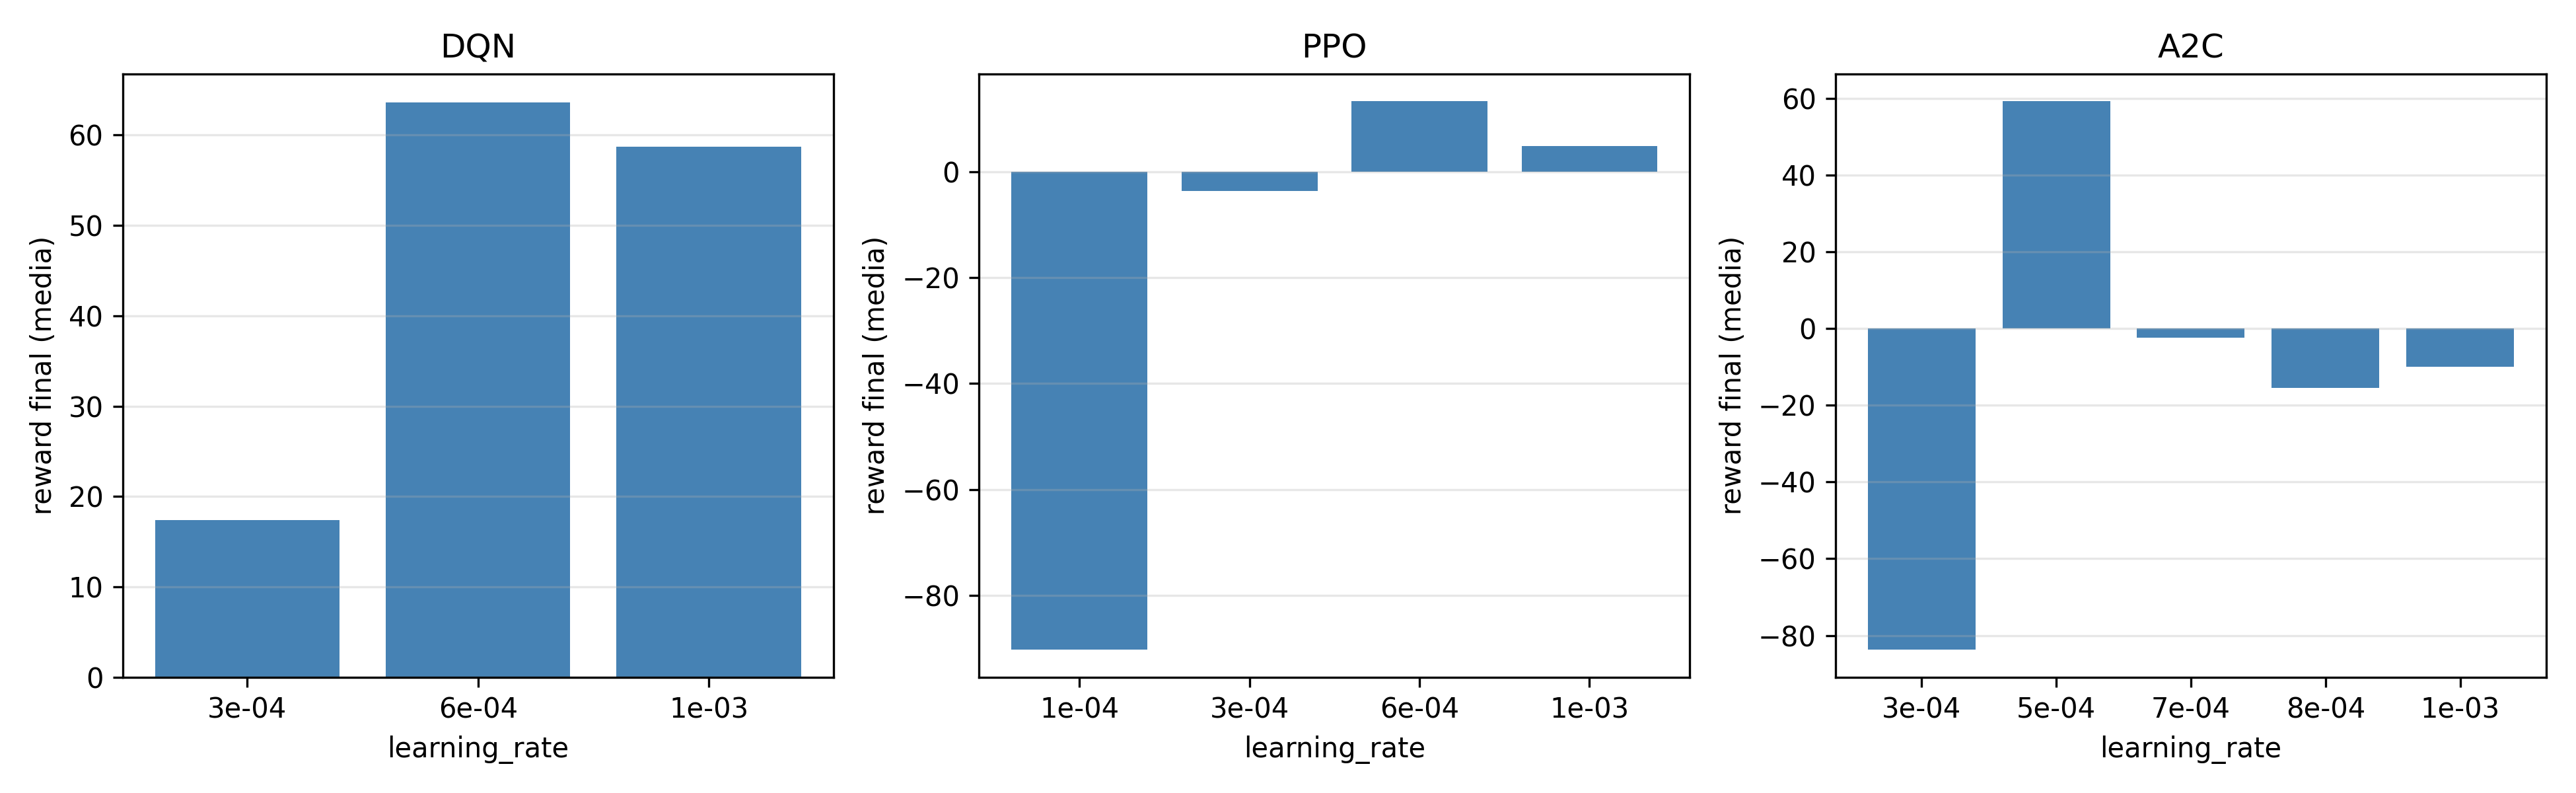

In [19]:
Image(os.path.join(AP2, 'comparativa_learning_rates.png'), width=900)

### Curvas de aprendizaje

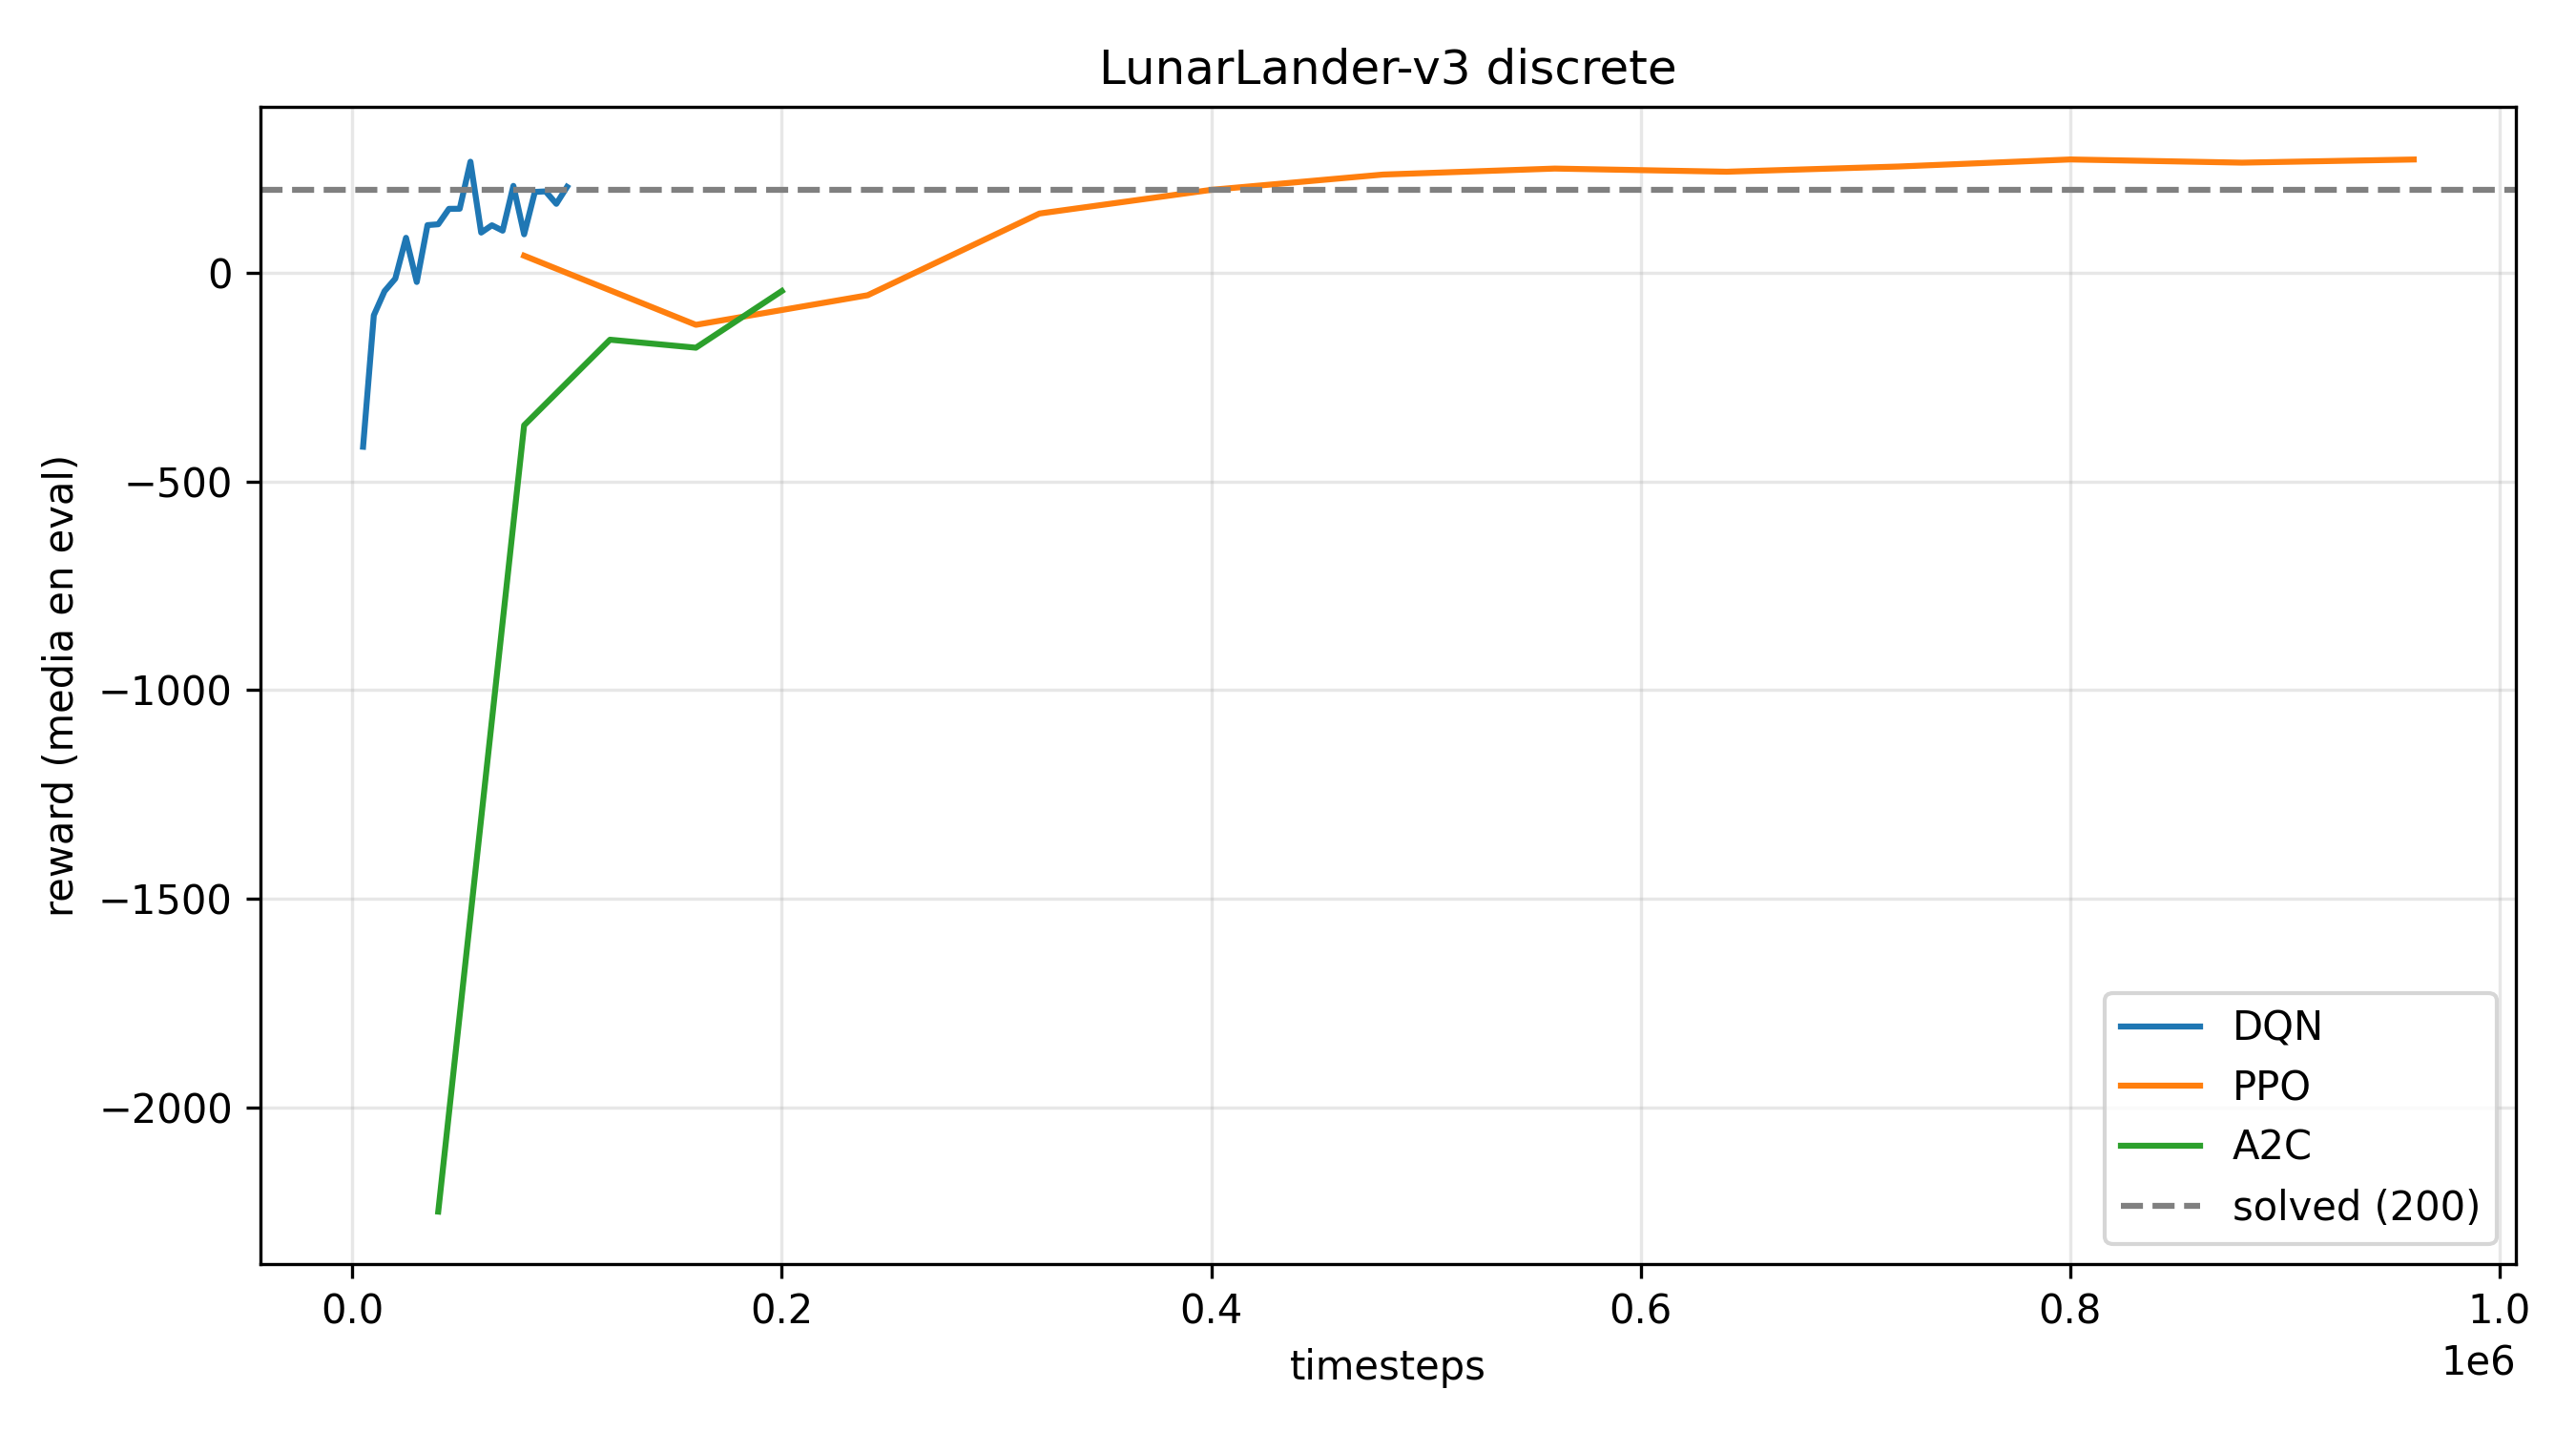

In [20]:
Image(os.path.join(AP2, 'comparativa_curvas_aprendizaje.png'), width=900)

### Evaluacion final (20 episodios)

- PPO gana con holgura (media más alta y mas estable). 
- DQN supera el umbral con 10x menos timesteps. 
- A2C no es capaz de resolver el entorno.

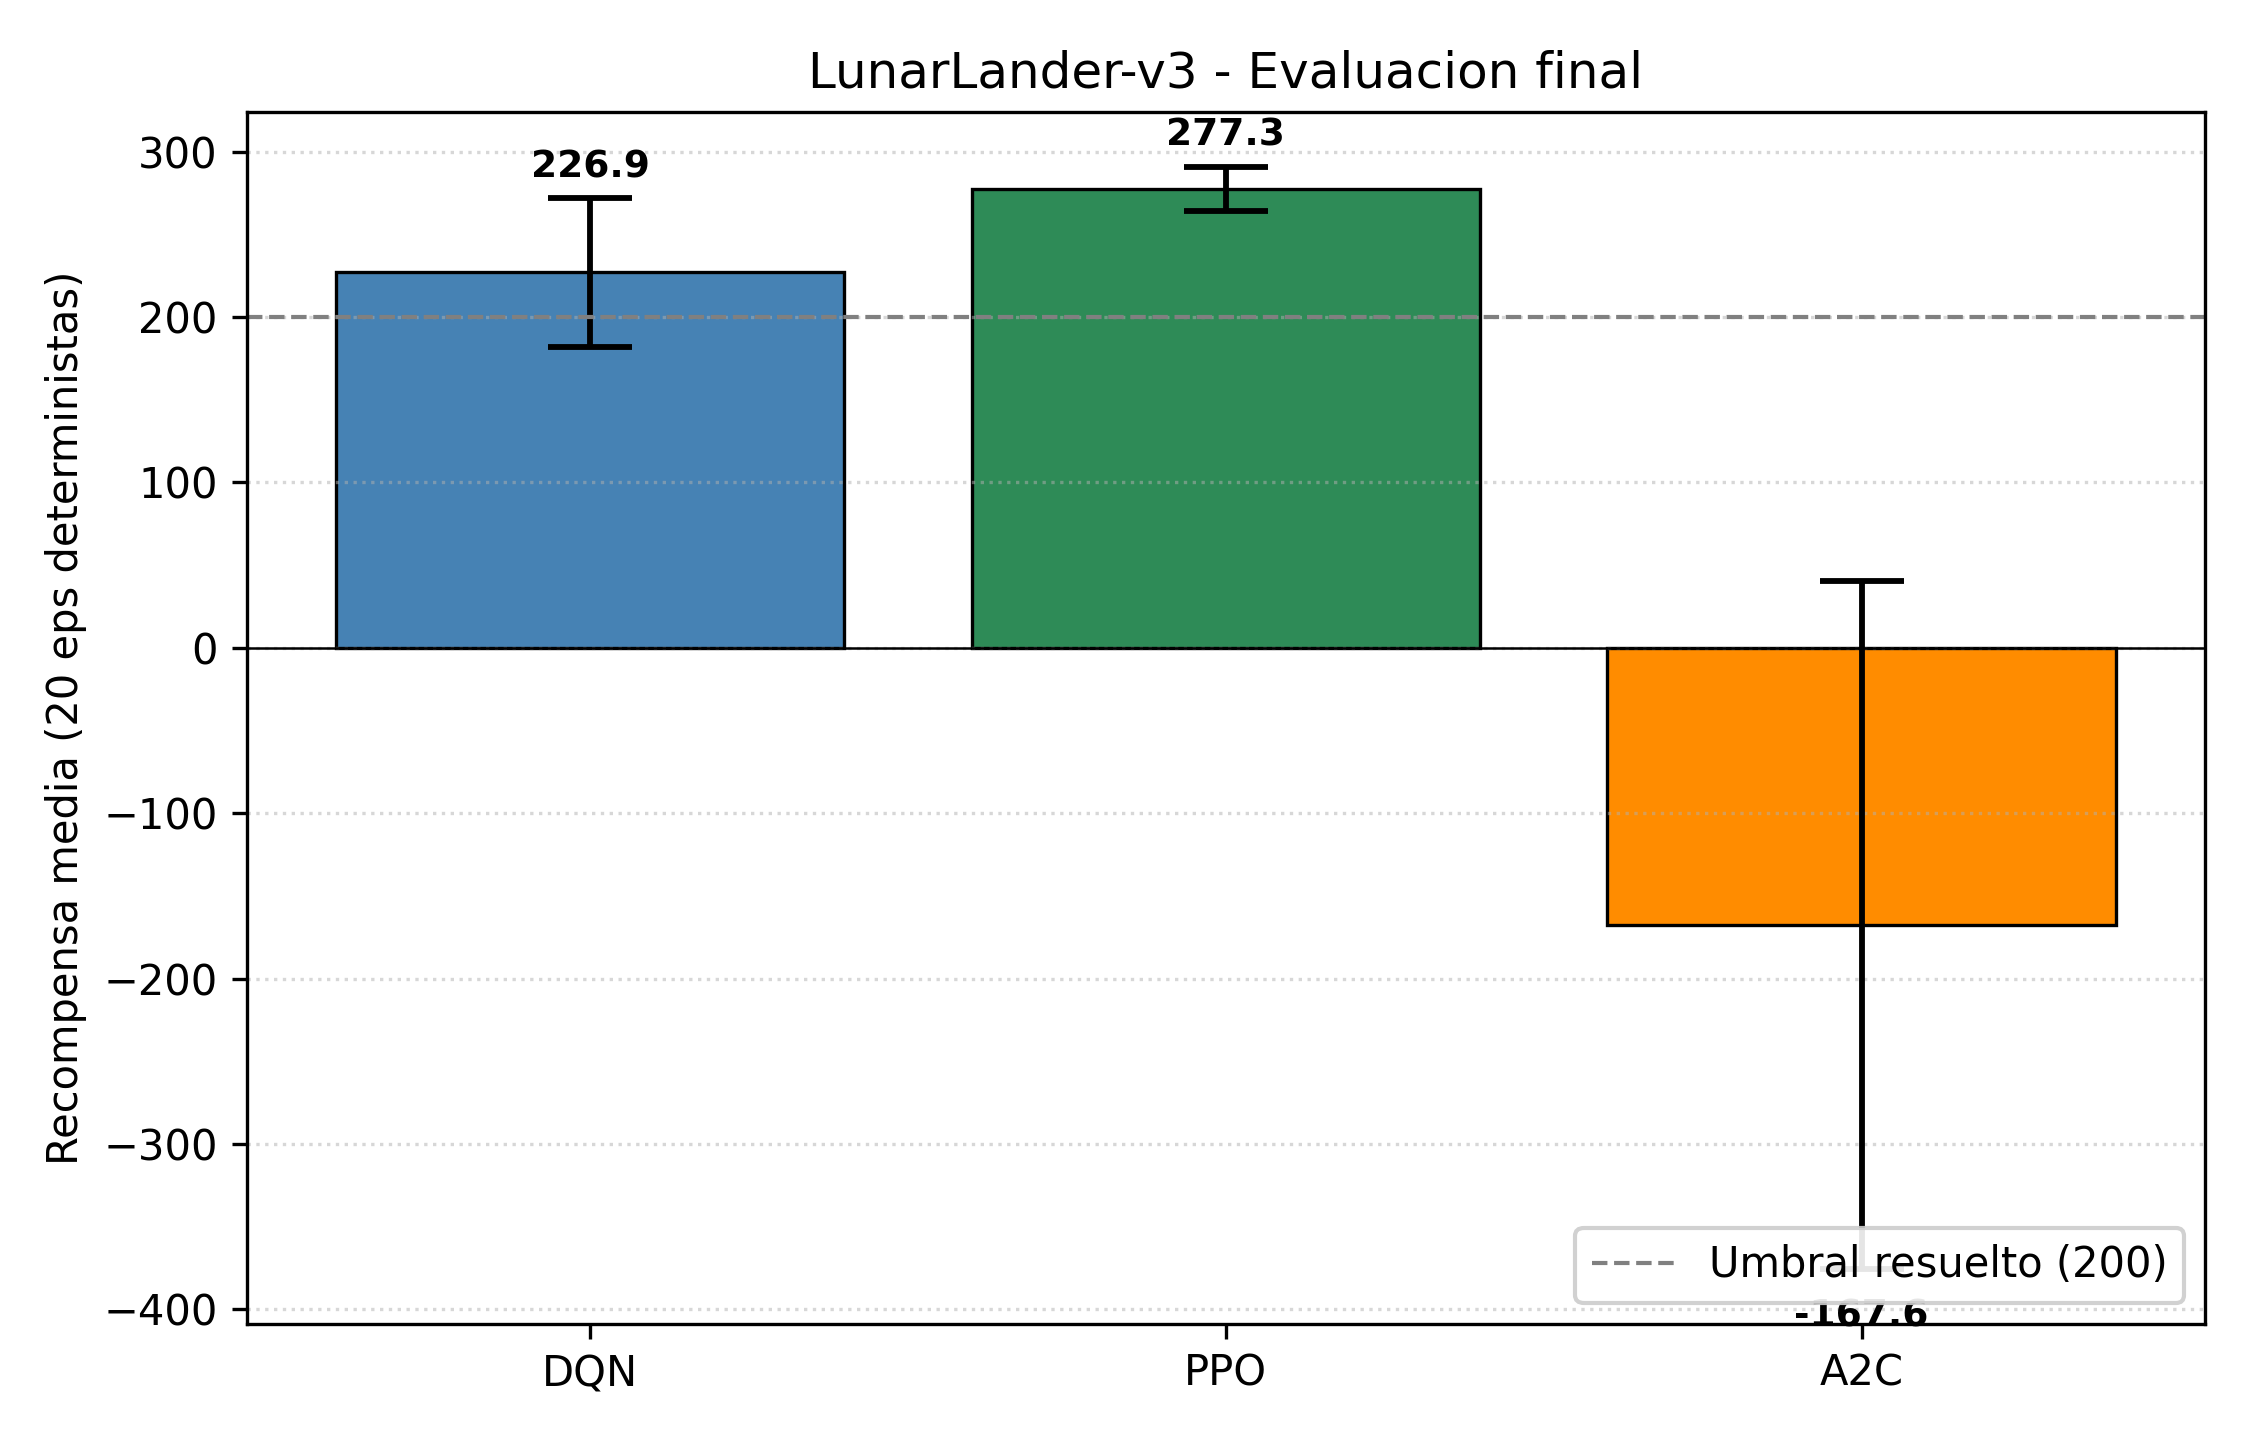

In [21]:
Image(os.path.join(AP2, 'comparativa_eval_final.png'), width=900)

### Video Ejemplo aterrizajes

Podemos ver en tiempo real los resultados expuestos en la gráfica

In [28]:
Video(os.path.join(AP2, 'videos_lunar/comparativa_3algos.mp4'), embed=True, width=1500)

### Video PPO Solo

In [23]:
Video(os.path.join(AP2, 'videos_lunar/ppo_lunarlander-episode-0.mp4'), embed=True, width=480)

## 4. Apartado 4.3: SpaceInvaders (Atari)

Para el proyecto libre se escoge: `ALE/SpaceInvaders-v5` con `CnnPolicy`. 

### Algoritmos

Se entrenan **DQN** y **PPO** con $10^6$ timesteps en 8 envs paralelos. Se emplea el preprocesado de atari. Tienen los siguientes hiperparámetros

#### DQN

```yml
atari:
  env_wrapper:
    - stable_baselines3.common.atari_wrappers.AtariWrapper
  frame_stack: 4
  policy: 'CnnPolicy'
  n_timesteps: !!float 1e7
  buffer_size: 100000
  learning_rate: !!float 1e-4
  batch_size: 32
  learning_starts: 100000
  target_update_interval: 1000
  train_freq: 4
  gradient_steps: 1
  exploration_fraction: 0.1
  exploration_final_eps: 0.01
  # If True, you need to deactivate handle_timeout_termination
  # in the replay_buffer_kwargs
  optimize_memory_usage: False
```

#### PPO

```yml
atari:
  env_wrapper:
    - stable_baselines3.common.atari_wrappers.AtariWrapper
  frame_stack: 4
  policy: 'CnnPolicy'
  n_envs: 8
  n_steps: 128
  n_epochs: 4
  batch_size: 256
  n_timesteps: !!float 1e7
  learning_rate: lin_2.5e-4
  clip_range: lin_0.1
  vf_coef: 0.5
  ent_coef: 0.01
```

### Curvas de aprendizaje

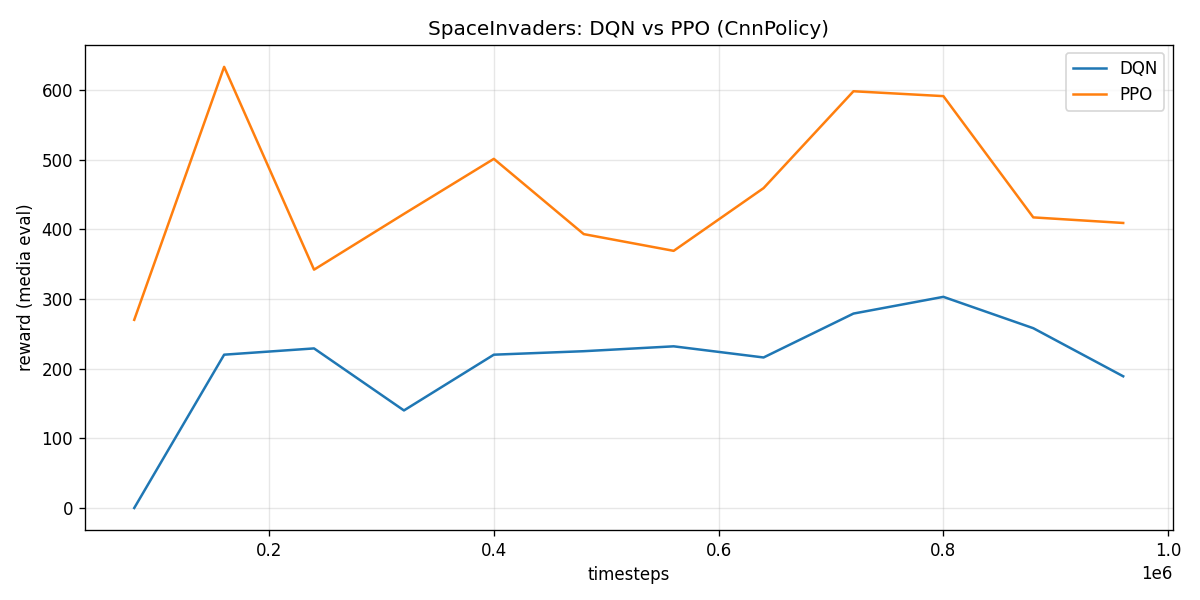

In [24]:
Image(os.path.join(AP3, 'spaceinvaders_curvas.png'), width=900)

### Evaluacion final (20 episodios)

PPO casi duplica el resultado de DQN, a costa de mayor varianza.

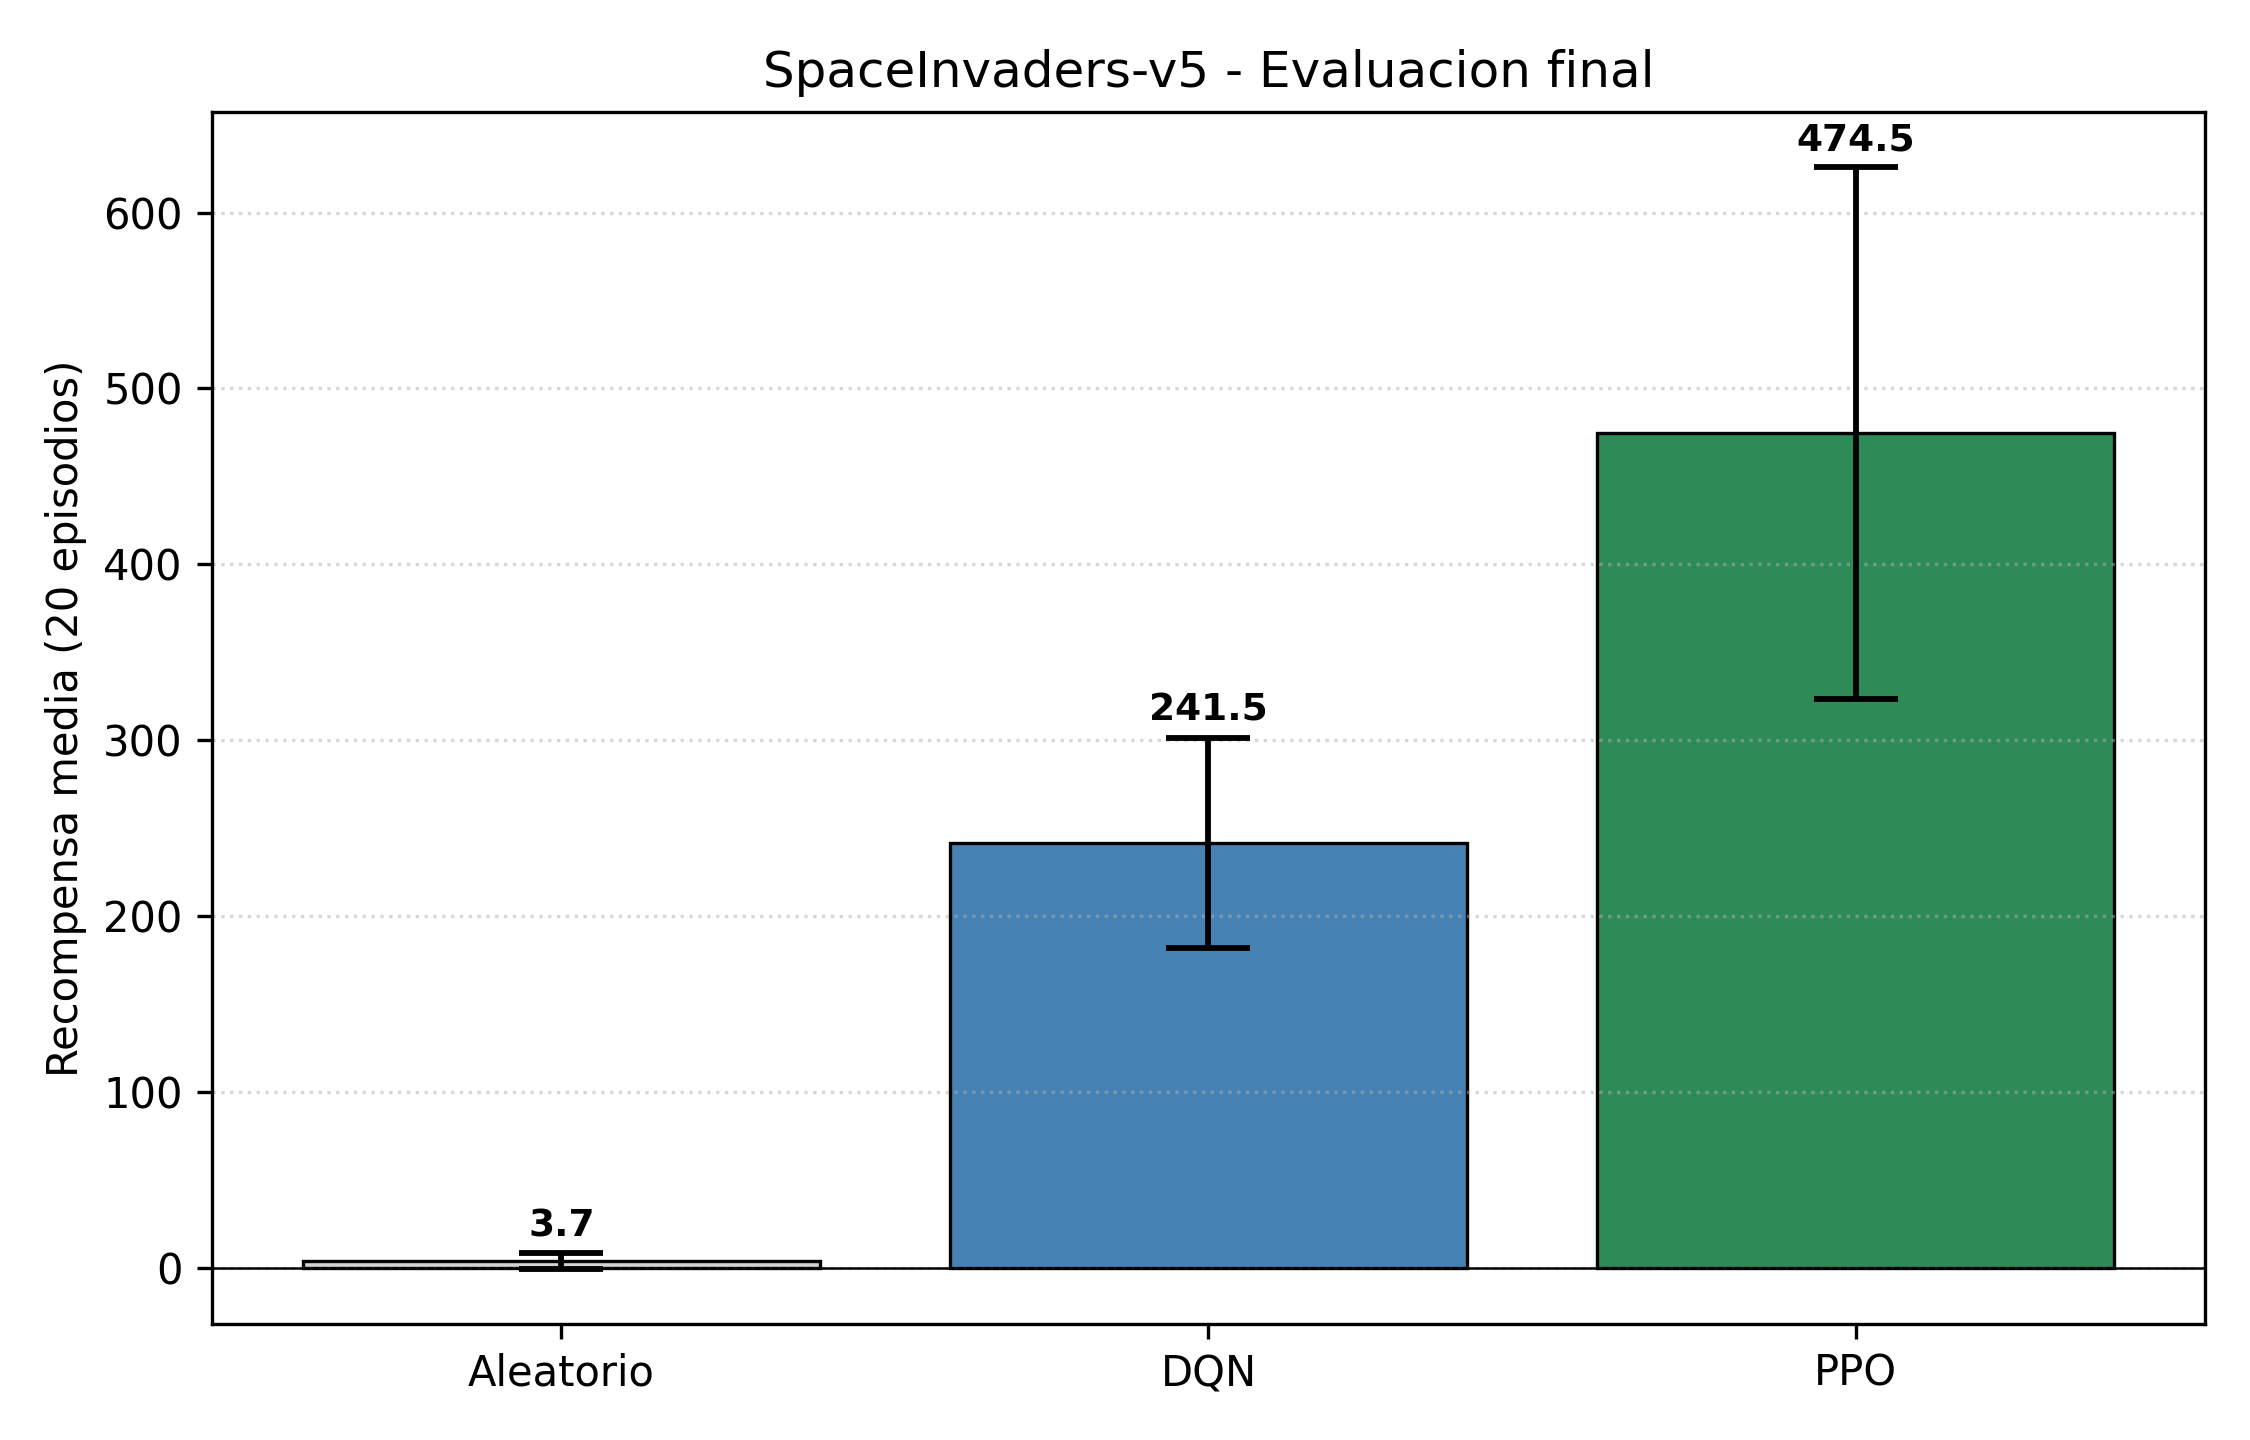

In [25]:
Image(os.path.join(AP3, 'eval_final.png'), width=900)

### Demo cada agente

In [26]:
display(Markdown('### DQN'))
Video(os.path.join(AP3, 'videos_dqn/dqn_spaceinvaders-step-0-to-step-5000.mp4'), embed=True, width=320)

### DQN

In [27]:
display(Markdown('### PPO'))
Video(os.path.join(AP3, 'videos_ppo/ppo_spaceinvaders-step-0-to-step-5000.mp4'), embed=True, width=320)

### PPO

# Resultados Finales

| Apartado | Entorno | Ganador | Resultado |
|---|---|---|---|
| 4.1 | CartPole-v1 | DQN | 500/500 -- resuelto |
| 4.2 | LunarLander-v3 | **PPO** | 271.8 +- 25.2 (DQN 236.3 +- 48.2, A2C falla) |
| 4.3 | SpaceInvaders-v5 | **PPO** | 474.5 +- 151.4 (DQN 241.5 +- 59.9) |

PPO es la opcion mas robusta en los dos entornos no triviales, pero DQN compite cuando la recompensa es densa y la observacion estructurada. No hay algoritmo universalmente superior; la adecuacion al problema manda.

Codigo, modelos y videos: <https://github.com/Jorge-A-V/RL-Practica2>